# MCU Benchmark Analysis

This notebook analyzes TinyML benchmark results for microcontroller (MCU) platforms, focusing on:
1. **Data Reading and Preprocessing**: Load and standardize CSV data
2. **Success Rate Plotting**: Visualize model success rates across stages
3. **Model Cost/Time Plotting**: Compare execution time and operational costs

## 1. Data Reading and Preprocessing

Load CSV files, standardize columns, and compute derived metrics for analysis.

### 1.1 Load and Standardize Data

In [25]:
from pathlib import Path

import numpy as np
import pandas as pd

# Resolve data directory (works from repo root or notebook folder)
DATA_DIR = Path().resolve()
CSV_FILE = DATA_DIR / "all-MCU2.csv"

# Canonical labels and ordering (single source of truth)
MODEL_LABELS = {
    "gpt-5": "G5",
    "gpt-4o": "G4o",
    "gpt-4o-mini": "G4o-m",
    "phi4": "Phi4",
    "qwen32": "Qw32B",
    "qwen14": "Qw14B",
    "codestral": "Co22B",
    "codestral-p": "Co22B-p",
    "gemma3": "Ge3",
}
PROCESSOR_LABELS = {
    "dp": "DP",
    "mc": "MC",
    "sg": "ArdSG",
    "psg": "PyCPU-SG",
    "tpusg": "PyTPU-SG",
}

MODEL_ORDER_PREF = list(MODEL_LABELS)
PROCESSOR_ORDER_PREF = list(PROCESSOR_LABELS)

if not CSV_FILE.exists():
    raise FileNotFoundError(f"CSV file not found: {CSV_FILE}")

df = pd.read_csv(CSV_FILE)
df.columns = df.columns.str.strip()

required_cols = {"status", "latency", "processor", "model"}
missing_cols = required_cols.difference(df.columns)
if missing_cols:
    raise ValueError(f"{CSV_FILE.name} is missing required columns: {sorted(missing_cols)}")

df = df.copy()
df["status"] = df["status"].astype(str).str.strip().str.lower()
df["status_group"] = np.where(df["status"].eq("success"), "success", "failure")
df["processor_std"] = df["processor"].astype(str).str.strip().str.lower()
df["model_std"] = df["model"].astype(str).str.strip().str.lower()

if "total_cost" not in df.columns:
    df["total_cost"] = np.nan

df["source_file"] = CSV_FILE.name
keep_cols = [
    "model_std",
    "processor_std",
    "status_group",
    "latency",
    "total_cost",
    "source_file",
    "model",
    "processor",
    "status",
]
df = df.loc[:, keep_cols]

print(f"Loaded file: {CSV_FILE.name}")
print(f"Total rows: {len(df)}")
print(f"Columns: {list(df.columns)}")

Loaded file: all-MCU2.csv
Total rows: 630
Columns: ['model_std', 'processor_std', 'status_group', 'latency', 'total_cost', 'source_file', 'model', 'processor', 'status']


### 1.2 Compute Derived Metrics

In [32]:
import pprint


def preferred_order(present, preferred):
    return [item for item in preferred if item in present] + [item for item in present if item not in preferred]


def model_label(model_key):
    return MODEL_LABELS.get(model_key, model_key)


models_present = list(df["model_std"].unique())
processors_present = list(df["processor_std"].unique())
model_order = preferred_order(models_present, MODEL_ORDER_PREF)
processor_order = preferred_order(processors_present, PROCESSOR_ORDER_PREF)

pivot_data = (
    df.groupby(["model_std", "processor_std", "status_group"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=["success", "failure"], fill_value=0)
)

success_rate_dict = {}
for (model, processor), row in pivot_data.iterrows():
    success_count = int(row["success"])
    failure_count = int(row["failure"])
    total = success_count + failure_count
    success_rate_dict[(model, processor)] = {
        "success_count": success_count,
        "failure_count": failure_count,
        "total": total,
        "success_rate": (success_count / total) if total else 0.0,
    }

print("Success rate summary (fraction):")
pprint.pprint(success_rate_dict)


def agg_mean(frame, metric):
    if frame.empty or metric not in frame:
        return {proc: 0.0 for proc in processor_order}
    return (
        frame.groupby("processor_std")[metric]
        .mean()
        .reindex(processor_order)
        .fillna(0.0)
        .to_dict()
    )


def safe_mean(frame, metric):
    if frame.empty or frame[metric].dropna().empty:
        return 0.0
    return float(frame[metric].mean())


def build_model_dict(model_key):
    subset = df[df["model_std"] == model_key]
    if subset.empty:
        return {"latency": {}, "cost": {}}

    pass_df = subset[subset["status_group"] == "success"]
    fail_df = subset[subset["status_group"] != "success"]

    return {
        "latency": {
            **agg_mean(pass_df, "latency"),
            "total": safe_mean(pass_df, "latency"),
            "total_x": safe_mean(fail_df, "latency"),
        },
        "cost": {
            **agg_mean(pass_df, "total_cost"),
            "total": safe_mean(pass_df, "total_cost"),
            "total_x": safe_mean(fail_df, "total_cost"),
        },
    }


models_by_volume = df["model_std"].value_counts().index.tolist()
gpt_models = [model for model in models_by_volume if isinstance(model, str) and "gpt" in model]
if not gpt_models:
    raise ValueError("No models containing 'gpt' found for comparison plot.")

primary_model = gpt_models[0]
secondary_model = gpt_models[1] if len(gpt_models) > 1 else None

primary_stats = build_model_dict(primary_model)
secondary_stats = build_model_dict(secondary_model) if secondary_model else None

COST_SCALE = 100
primary_stats["cost"] = {key: (value or 0) * COST_SCALE for key, value in primary_stats["cost"].items()}
if secondary_stats:
    secondary_stats["cost"] = {key: (value or 0) * COST_SCALE for key, value in secondary_stats["cost"].items()}

print("\n" + "=" * 80)
print("Primary model:", model_label(primary_model))
print("=" * 80)
pprint.pprint(primary_stats)
if secondary_stats:
    print("\n" + "=" * 80)
    print("Secondary model:", model_label(secondary_model))
    print("=" * 80)
    pprint.pprint(secondary_stats)

Success rate summary (fraction):
{('codestral', 'dp'): {'failure_count': 19,
                       'success_count': 11,
                       'success_rate': 0.36666666666666664,
                       'total': 30},
 ('codestral', 'mc'): {'failure_count': 14,
                       'success_count': 16,
                       'success_rate': 0.5333333333333333,
                       'total': 30},
 ('codestral', 'sg'): {'failure_count': 30,
                       'success_count': 0,
                       'success_rate': 0.0,
                       'total': 30},
 ('codestral-p', 'dp'): {'failure_count': 12,
                         'success_count': 18,
                         'success_rate': 0.6,
                         'total': 30},
 ('codestral-p', 'mc'): {'failure_count': 6,
                         'success_count': 24,
                         'success_rate': 0.8,
                         'total': 30},
 ('codestral-p', 'sg'): {'failure_count': 29,
                         'succe

## 2. Success Rate Plotting

Visualize success rates for each model across different processor stages using a heatmap with progress bars.

figure size: 8.0 x 4.5


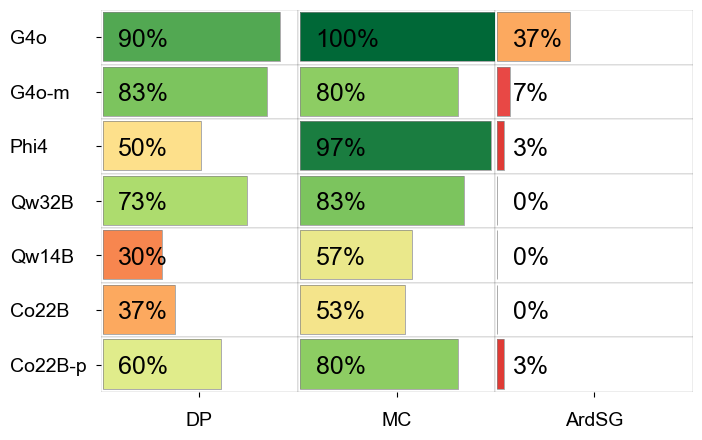

In [33]:
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap


def build_heatmap_dataframe(success_rates):
    rows = []
    for (model, processor), data in success_rates.items():
        rate = data["success_rate"]
        rows.append(
            {
                "model": model_label(model),
                "processor": str(processor),
                "success_rate": (rate * 100) if rate <= 1 else rate,
            }
        )

    table = pd.DataFrame(rows).pivot(index="model", columns="processor", values="success_rate")
    return table.reindex(
        index=[model_label(model) for model in model_order],
        columns=processor_order,
    )


heatmap_df = build_heatmap_dataframe(success_rate_dict)

plt.rcParams["font.family"] = "Arial"
fig_width, fig_height = 8, 4.5
print(f"figure size: {fig_width:.1f} x {fig_height:.1f}")
fig, ax = plt.subplots(figsize=(fig_width, fig_height))

cmap = LinearSegmentedColormap.from_list(
    "custom",
    [
        "#D73027",
        "#F65D5F",
        "#F46D43",
        "#FDAE61",
        "#FEE08B",
        "#D9EF8B",
        "#A6D96A",
        "#68BA59",
        "#006837",
    ],
    N=256,
)

ax.set_xlim(0, len(heatmap_df.columns))
ax.set_ylim(0, len(heatmap_df.index))
ax.invert_yaxis()

bar_height_ratio = 0.9
gap = 0


def draw_progress_cell(i, j, value):
    bg_rect = mpatches.Rectangle(
        (j + gap / 2, i + gap / 2),
        1 - gap,
        1 - gap,
        facecolor="white",
        edgecolor="black",
        linewidth=0.1,
    )
    ax.add_patch(bg_rect)

    bar_height = bar_height_ratio
    y_offset = (1 - bar_height) / 2 - 0.01
    x_offset = 0.01
    bar_width = value / 100

    bar_rect = mpatches.Rectangle(
        (j + x_offset, i + y_offset),
        bar_width,
        bar_height,
        facecolor=cmap(value / 100),
        edgecolor="none",
        linewidth=0,
    )
    ax.add_patch(bar_rect)

    bar_border = mpatches.Rectangle(
        (j + x_offset, i + y_offset),
        bar_width,
        bar_height,
        facecolor="none",
        edgecolor="#888888",
        linewidth=0.5,
    )
    ax.add_patch(bar_border)

    ax.text(
        j + 0.09,
        i + 0.55,
        f"{value:.0f}%",
        ha="left",
        va="center",
        fontsize=18,
        weight="regular",
        color="black",
    )


for i, model in enumerate(heatmap_df.index):
    for j, processor in enumerate(heatmap_df.columns):
        value = heatmap_df.loc[model, processor]
        if pd.notna(value):
            draw_progress_cell(i, j, value)

ax.set_xticks([i + 0.5 for i in range(len(heatmap_df.columns))])
ax.set_yticks([i + 0.5 for i in range(len(heatmap_df.index))])
ax.set_xticklabels(
    [str(PROCESSOR_LABELS.get(str(col), str(col))) for col in heatmap_df.columns],
    fontsize=14,
    weight="regular",
)
ax.set_yticklabels(heatmap_df.index, fontsize=14)
for label in ax.get_yticklabels():
    label.set_horizontalalignment("left")
    label.set_x(-0.18)

ax.tick_params(axis="both", which="both")
ax.tick_params(axis="y", pad=-15)
ax.tick_params(axis="x", pad=11)
ax.spines["left"].set_visible(True)

for spine in ax.spines.values():
    spine.set_visible(False)

plt.subplots_adjust(left=0.22)
plt.tight_layout(rect=(0.12, 0, 1, 1))
plt.savefig("figs/with-additional-g5-success-rate_MCU.pdf", dpi=300, bbox_inches="tight")
plt.show()

## 3. Model Cost/Time Plotting

Compare execution time and operational costs between GPT models across processor stages.

Figure size: 8.0 x 5.6


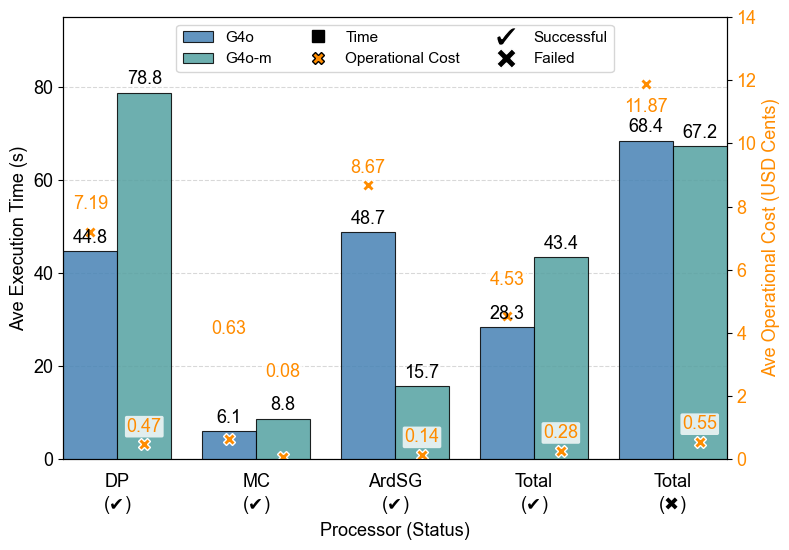


Plot saved as 'figs/g5-g4o-g4om_mcu_comparison.pdf'


In [29]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D
from matplotlib.ticker import MaxNLocator

COLORS = {
    "primary_bar": "steelblue",
    "secondary_bar": "#54a1a1",
    "cost_annotation": "darkorange",
    "cost_axis": "darkorange",
    "legend_cost_marker_face": "darkorange",
    "background": "#ffffff",
    "text": "#000000",
    "time_axis": "black",
    "grid": "gray",
    "cost_marker_edge": "white",
    "cost_label_box": "white",
    "cost_label_box_edge": "none",
    "legend_cost_marker_edge": "black",
}

FONT = {
    "family": "Arial",
    "base": 13,
    "weight_regular": "regular",
    "label_weight": "regular",
    "ylabel_plus": 0,
    "xtick_plus": 0,
    "cost_label_minus": 0,
    "legend_minus": 2,
}
plt.rcParams["font.family"] = FONT["family"]

FIGURE = {
    "min_width": 8.0,
    "width_per_category": 0.75,
    "base_height": 5.0,
    "height_per_category": 0.12,
    "marker_size_base": 8,
    "marker_size_width_scale": 0.4,
    "marker_size_width_offset": 5.0,
}

BARS = {
    "max_width": 0.35,
    "total_span": 0.8,
    "edgecolor": "black",
    "linewidth": 0.8,
    "alpha": 0.85,
    "zorder": 3,
}

AXIS = {
    "time_label": "Ave Execution Time (s)",
    "cost_label": "Ave Operational Cost (USD Cents)",
    "xlabel": "Processor (Status)",
    "x_tick_pad": 10,
    "grid_linestyle": "--",
    "grid_alpha": 0.3,
    "grid_zorder": 0,
    "time_nbins": 5,
}

COST_ANNOTATION = {
    "marker": "X",
    "marker_edge_width": 1,
    "marker_zorder": 5,
    "time_label_offset_ratio": 0.01,
    "cost_label_default_offset_ratio": 0.04,
    "cost_label_low_marker_offset_ratio": 0.10,
    "cost_label_low_marker_trigger_ratio": 0.15,
    "text_height_ratio": 0.08,
    "overlap_margin_ratio": 1.2,
    "time_overlap_buffer_ratio": 0.3,
    "horizontal_threshold_width_ratio": 1.5,
    "max_attempts": 10,
    "max_label_height_ratio": 0.85,
    "fallback_below_marker_ratio": 0.05,
    "fallback_min_ratio": 0.02,
    "cost_box_style": "round,pad=0.1",
    "cost_box_alpha": 0.8,
    "cost_text_format": "{cost:.2f}",
    "time_text_format": "{time:.1f}",
    "cost_text_ha": "center",
    "cost_text_va": "center",
    "time_text_ha": "center",
    "time_text_va": "bottom",
}

LEGEND = {
    "loc": "upper center",
    "frameon": True,
    "fancybox": True,
    "shadow": False,
    "ncol": 3,
    "time_label": "Time",
    "cost_label": "Operational Cost",
    "success_label": "Successful",
    "fail_label": "Failed",
    "success_marker": "$✔$",
    "fail_marker": "$✖$",
}

EXPORT = {"file": "figs/g5-g4o-g4om_mcu_comparison.pdf", "dpi": 300, "bbox_inches": "tight"}

keys = processor_order + ["total", "total_x"]
categories = [f"{PROCESSOR_LABELS.get(p, p)}\n($✔$)" for p in processor_order] + ["Total\n($✔$)", "Total\n($✖$)"]

model_stats_by_key = {}
if primary_model and primary_stats:
    model_stats_by_key[primary_model] = primary_stats
if secondary_model and secondary_stats:
    model_stats_by_key[secondary_model] = secondary_stats

ordered_model_keys = [m for m in ("gpt-4o", "gpt-4o-mini") if m in model_stats_by_key]
ordered_model_keys += [m for m in model_stats_by_key if m not in ordered_model_keys]

if not ordered_model_keys:
    raise ValueError("No model stats available for the cost/time comparison plot.")

first_model = ordered_model_keys[0]
first_stats = model_stats_by_key[first_model]
first_label = MODEL_LABELS.get(first_model, first_model)

second_model = ordered_model_keys[1] if len(ordered_model_keys) > 1 else None
second_stats = model_stats_by_key[second_model] if second_model else None
second_label = MODEL_LABELS.get(second_model, second_model) if second_model else None


def extract_metrics(stats, metric_keys):
    return (
        np.array([stats["latency"].get(k, 0) for k in metric_keys]),
        np.array([stats["cost"].get(k, 0) for k in metric_keys]),
    )


times_first, costs_first = extract_metrics(first_stats, keys)
times_second, costs_second = (
    extract_metrics(second_stats, keys)
    if second_stats
    else (np.zeros_like(times_first), np.zeros_like(costs_first))
)

num_categories = len(categories)
series_count = len(ordered_model_keys)
fig_width = max(FIGURE["min_width"], num_categories * FIGURE["width_per_category"])
fig_height = FIGURE["base_height"] + FIGURE["height_per_category"] * num_categories
print(f"Figure size: {fig_width} x {fig_height}")
font_base = FONT["base"]
marker_size = FIGURE["marker_size_base"] + (fig_width - FIGURE["marker_size_width_offset"]) * FIGURE["marker_size_width_scale"]


def nice_limit(value, pct_pad, step):
    return float(np.ceil(max(value, step) * (1 + pct_pad) / step) * step)


max_time = np.nanmax([times_first.max(), times_second.max()])
max_cost = np.nanmax([costs_first.max(), costs_second.max()])
y_max_time = nice_limit(max_time, 0.2, 5)
y_max_cost = nice_limit(max_cost, 0.15, 0.5)

x = np.arange(num_categories) * 0.9
width = min(BARS["max_width"], BARS["total_span"] / max(series_count, 1))
offset = width / 2 if series_count == 2 else 0.0

fig, ax1 = plt.subplots(figsize=(fig_width, fig_height))
fig.patch.set_facecolor(COLORS["background"])
ax1.set_facecolor(COLORS["background"])

bars_first = ax1.bar(
    x - offset,
    times_first,
    width,
    color=COLORS["primary_bar"],
    edgecolor=BARS["edgecolor"],
    linewidth=BARS["linewidth"],
    alpha=BARS["alpha"],
    zorder=BARS["zorder"],
    label=f"{first_label}",
)
bars_second = (
    ax1.bar(
        x + offset,
        times_second,
        width,
        color=COLORS["secondary_bar"],
        edgecolor=BARS["edgecolor"],
        linewidth=BARS["linewidth"],
        alpha=BARS["alpha"],
        zorder=BARS["zorder"],
        label=f"{second_label}",
    )
    if second_stats
    else []
)

ax1.set_ylabel(
    AXIS["time_label"],
    fontsize=font_base + FONT["ylabel_plus"],
    fontweight=FONT["weight_regular"],
    color=COLORS["time_axis"],
)
ax1.set_ylim(0, y_max_time)
ax1.set_xticks(x)
ax1.set_xticklabels(categories, fontsize=font_base + FONT["xtick_plus"], fontweight=FONT["weight_regular"])
ax1.tick_params(axis="y", labelsize=font_base, labelcolor=COLORS["time_axis"])
ax1.tick_params(axis="x", length=0, pad=AXIS["x_tick_pad"])
ax1.grid(axis="y", linestyle=AXIS["grid_linestyle"], alpha=AXIS["grid_alpha"], color=COLORS["grid"], zorder=AXIS["grid_zorder"])
ax1.yaxis.set_major_locator(MaxNLocator(nbins=AXIS["time_nbins"]))
ax1.set_xlim(-width, x[-1] + width)

ax2 = ax1.twinx()
ax2.set_ylabel(
    AXIS["cost_label"],
    fontsize=font_base + FONT["ylabel_plus"],
    fontweight=FONT["weight_regular"],
    color=COLORS["cost_axis"],
)
ax2.set_ylim(0, y_max_cost)
ax2.tick_params(axis="y", labelsize=font_base, labelcolor=COLORS["cost_axis"])

placed_cost_labels = []


def add_annotations(bars, times, costs):
    if not bars:
        return

    cost_y_positions = (costs / y_max_cost * y_max_time) if y_max_cost else np.zeros_like(costs)

    for idx, (bar, time, cost, cost_y) in enumerate(zip(bars, times, costs, cost_y_positions), start=1):
        x_center = bar.get_x() + bar.get_width() / 2

        ax1.plot(
            x_center,
            cost_y,
            marker=COST_ANNOTATION["marker"],
            color=COLORS["cost_annotation"],
            markersize=marker_size,
            markeredgecolor=COLORS["cost_marker_edge"],
            markeredgewidth=COST_ANNOTATION["marker_edge_width"],
            zorder=COST_ANNOTATION["marker_zorder"],
        )

        time_label_y = bar.get_height() + y_max_time * COST_ANNOTATION["time_label_offset_ratio"]
        label_y = cost_y + (
            y_max_time
            * (
                COST_ANNOTATION["cost_label_low_marker_offset_ratio"]
                if cost_y < y_max_time * COST_ANNOTATION["cost_label_low_marker_trigger_ratio"] and idx == 2
                else COST_ANNOTATION["cost_label_default_offset_ratio"]
            )
        )

        text_height_estimate = y_max_time * COST_ANNOTATION["text_height_ratio"]
        overlap_threshold = text_height_estimate * COST_ANNOTATION["overlap_margin_ratio"]
        if abs(label_y - time_label_y) < overlap_threshold:
            label_y = time_label_y + overlap_threshold

        horizontal_threshold = width * COST_ANNOTATION["horizontal_threshold_width_ratio"]
        for _ in range(COST_ANNOTATION["max_attempts"]):
            has_overlap = False
            for placed_x, placed_y in placed_cost_labels:
                x_dist = abs(x_center - placed_x)
                y_dist = abs(label_y - placed_y)
                if x_dist < horizontal_threshold and y_dist < overlap_threshold:
                    has_overlap = True
                    label_y = placed_y + overlap_threshold
                    break
            if not has_overlap:
                break

        max_label_height = y_max_time * COST_ANNOTATION["max_label_height_ratio"]
        if label_y > max_label_height:
            label_y = cost_y - (y_max_time * COST_ANNOTATION["fallback_below_marker_ratio"])
            label_y = max(label_y, y_max_time * COST_ANNOTATION["fallback_min_ratio"])

        placed_cost_labels.append((x_center, label_y))

        ax1.text(
            x_center,
            label_y,
            COST_ANNOTATION["cost_text_format"].format(cost=cost),
            ha=COST_ANNOTATION["cost_text_ha"],
            va=COST_ANNOTATION["cost_text_va"],
            fontsize=font_base - FONT["cost_label_minus"],
            fontweight=FONT["label_weight"],
            color=COLORS["cost_annotation"],
            bbox=dict(
                boxstyle=COST_ANNOTATION["cost_box_style"],
                fc=COLORS["cost_label_box"],
                ec=COLORS["cost_label_box_edge"],
                alpha=COST_ANNOTATION["cost_box_alpha"],
            ),
            zorder=6,
        )

        ax1.text(
            x_center,
            time_label_y,
            COST_ANNOTATION["time_text_format"].format(time=time),
            ha=COST_ANNOTATION["time_text_ha"],
            va=COST_ANNOTATION["time_text_va"],
            fontsize=font_base,
            fontweight=FONT["label_weight"],
            color=COLORS["text"],
            zorder=5,
        )


add_annotations(bars_second, times_second, costs_second)
add_annotations(bars_first, times_first, costs_first)

ax1.set_xlabel(
    AXIS["xlabel"],
    fontsize=font_base + FONT["ylabel_plus"],
    fontweight=FONT["weight_regular"],
)

handles1, labels1 = ax1.get_legend_handles_labels()
time_legend = Line2D(
    [0],
    [0],
    color=COLORS["time_axis"],
    marker="s",
    linestyle="",
    markersize=marker_size,
    label=LEGEND["time_label"],
    markerfacecolor=COLORS["time_axis"],
)
cost_legend = Line2D(
    [0],
    [0],
    marker=COST_ANNOTATION["marker"],
    color="w",
    markerfacecolor=COLORS["legend_cost_marker_face"],
    markersize=marker_size,
    markeredgecolor=COLORS["legend_cost_marker_edge"],
    label=LEGEND["cost_label"],
)
success_legend = Line2D(
    [0],
    [0],
    marker=LEGEND["success_marker"],
    color="w",
    mfc="black",
    ms=marker_size + 5,
    label=LEGEND["success_label"],
)
fail_legend = Line2D(
    [0],
    [0],
    marker=LEGEND["fail_marker"],
    color="w",
    mfc="black",
    ms=marker_size + 5,
    label=LEGEND["fail_label"],
)

all_handles = handles1 + [time_legend, cost_legend, success_legend, fail_legend]
all_labels = labels1 + [LEGEND["time_label"], LEGEND["cost_label"], LEGEND["success_label"], LEGEND["fail_label"]]

ax1.legend(
    all_handles,
    all_labels,
    loc=LEGEND["loc"],
    fontsize=font_base - FONT["legend_minus"],
    title_fontsize=font_base,
    frameon=LEGEND["frameon"],
    fancybox=LEGEND["fancybox"],
    shadow=LEGEND["shadow"],
    ncol=LEGEND["ncol"],
)

plt.tight_layout()
plt.savefig(EXPORT["file"], dpi=EXPORT["dpi"], bbox_inches=EXPORT["bbox_inches"])
plt.show()

print(f"\nPlot saved as '{EXPORT['file']}'")

# The statistics export was deleted by accident, but should be able to be restored from the previous commits. No further edits were done to this part since cloned to laptop